# PCA Analysis for Tournament Model Data

This notebook performs PCA on `data/tournament_model_ml.csv`, visualizes explained variance and principal components, and saves PCA-transformed train/test datasets as CSV files.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load the dataset
df = pd.read_csv('data/tournament_model_ml.csv')

features = ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff',
            'TOV_diff', 'TRB_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']

train = df[df['season'] <= 2022].reset_index(drop=True)
test = df[df['season'] >= 2023].reset_index(drop=True)

X_train = train[features]
y_train = train['win_label']
X_test = test[features]
y_test = test['win_label']

print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print('Feature columns:', features)

Train rows: 754 | Test rows: 314
Feature columns: ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff', 'TOV_diff', 'TRB_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']


# PCA Analysis for Tournament Model Data

# PCA Analysis for Tournament Model Data

This notebook performs PCA on `data/tournament_model_ml.csv`, visualizes explained variance and principal components, and saves PCA-transformed train/test datasets as CSV files.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
# Load the dataset
df = pd.read_csv('data/tournament_model_ml.csv')

features = ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff',
            'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']

train = df[df['season'] <= 2022].reset_index(drop=True)
test = df[df['season'] >= 2023].reset_index(drop=True)

X_train = train[features]
y_train = train['win_label']
X_test = test[features]
y_test = test['win_label']

print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print('Feature columns:', features)

Train rows: 754 | Test rows: 314
Feature columns: ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff', 'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']


In [5]:
# Fit PCA with scaling on the training set
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pipeline.fit(X_train)
pca = pipeline.named_steps['pca']
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Explained variance ratio by principal component:')
for i, ratio in enumerate(explained_variance, start=1):
    print(f'  PC{i}: {ratio:.4f}')

print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_variance, start=1):
    print(f'  PC{i}: {cum:.4f}')

Explained variance ratio by principal component:
  PC1: 0.4353
  PC2: 0.2009
  PC3: 0.1224
  PC4: 0.0830
  PC5: 0.0552
  PC6: 0.0399
  PC7: 0.0372
  PC8: 0.0194
  PC9: 0.0066

Cumulative explained variance:
  PC1: 0.4353
  PC2: 0.6362
  PC3: 0.7586
  PC4: 0.8416
  PC5: 0.8968
  PC6: 0.9368
  PC7: 0.9739
  PC8: 0.9934
  PC9: 1.0000


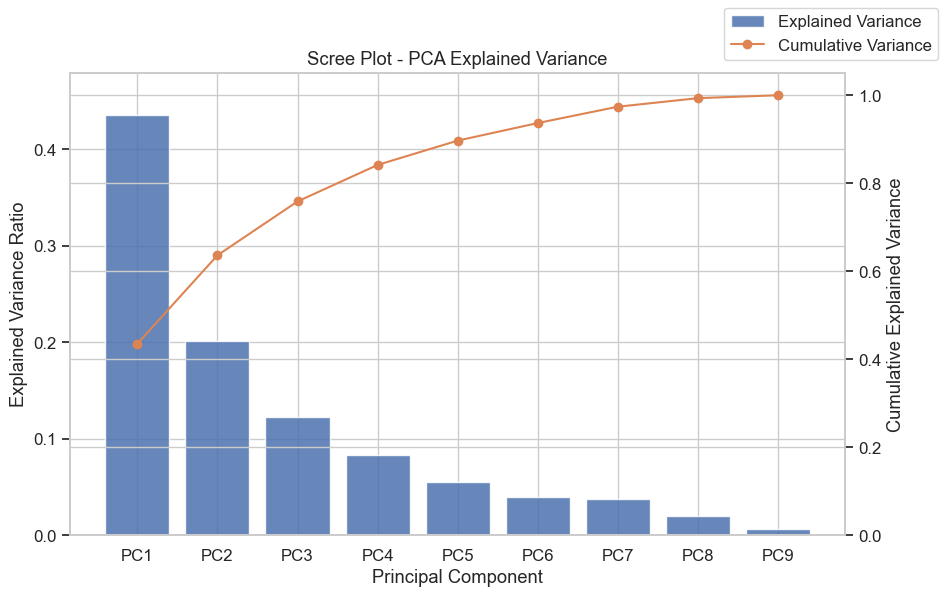

In [6]:
# Scree plot and cumulative variance plot
pc_labels = [f'PC{i+1}' for i in range(len(explained_variance))]

fig, ax1 = plt.subplots()
ax1.bar(pc_labels, explained_variance, color='#4c72b0', alpha=0.85, label='Explained Variance')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component')
ax1.set_title('Scree Plot - PCA Explained Variance')
ax1.set_ylim(0, explained_variance.max() * 1.1)

ax2 = ax1.twinx()
ax2.plot(pc_labels, cumulative_variance, color='#dd8452', marker='o', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

fig.legend(loc='upper right')
plt.show()

In [7]:
# Project the data onto the first three principal components
n_components = 3
pca_model = PCA(n_components=n_components)
X_train_scaled = pipeline.named_steps['scaler'].transform(X_train)
X_train_pca = pd.DataFrame(
    pca_model.fit_transform(X_train_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_train.index
)
train_pca_inspect = pd.concat([train[['season', 'win_label']].reset_index(drop=True), X_train_pca.reset_index(drop=True)], axis=1)
train_pca_inspect.head()

,season,win_label,PC1,PC2,PC3
0,2015,1,2.800673,1.728798,-1.613391
1,2015,1,1.595223,-1.375904,-0.320133
2,2015,1,0.502696,2.005143,-2.216379
3,2015,1,0.239608,-0.864773,1.263662
4,2015,1,1.691296,1.660130,-0.762817


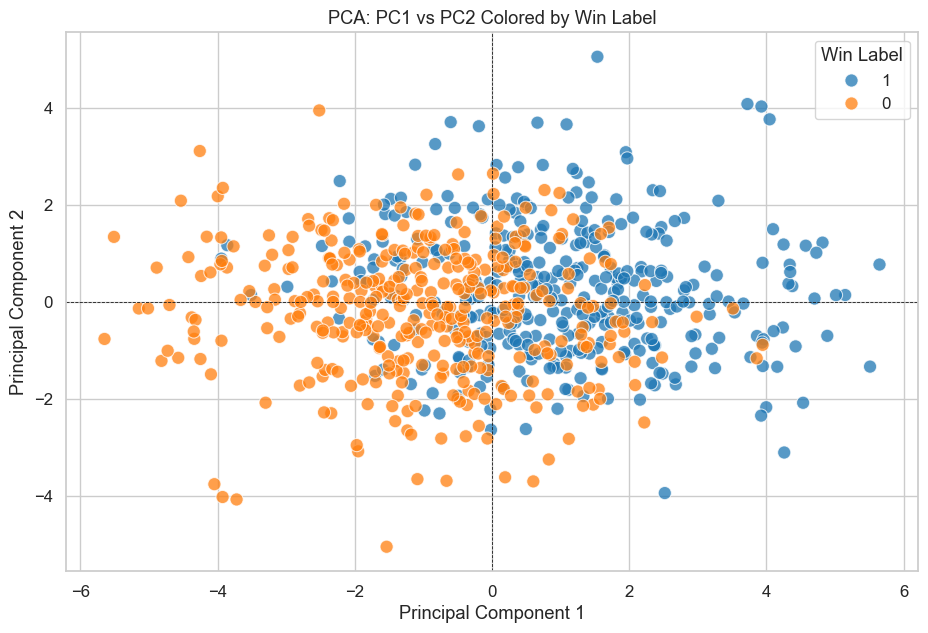

In [8]:
# 2D scatter plot for PC1 vs PC2
pca_train_plot = train_pca_inspect.copy()
pca_train_plot['win_label'] = pca_train_plot['win_label'].astype(str)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_train_plot,
    x='PC1',
    y='PC2',
    hue='win_label',
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.75,
    edgecolor='w',
    s=90
)
plt.title('PCA: PC1 vs PC2 Colored by Win Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Win Label')
plt.axhline(0, color='k', linewidth=0.6, linestyle='--')
plt.axvline(0, color='k', linewidth=0.6, linestyle='--')
plt.show()

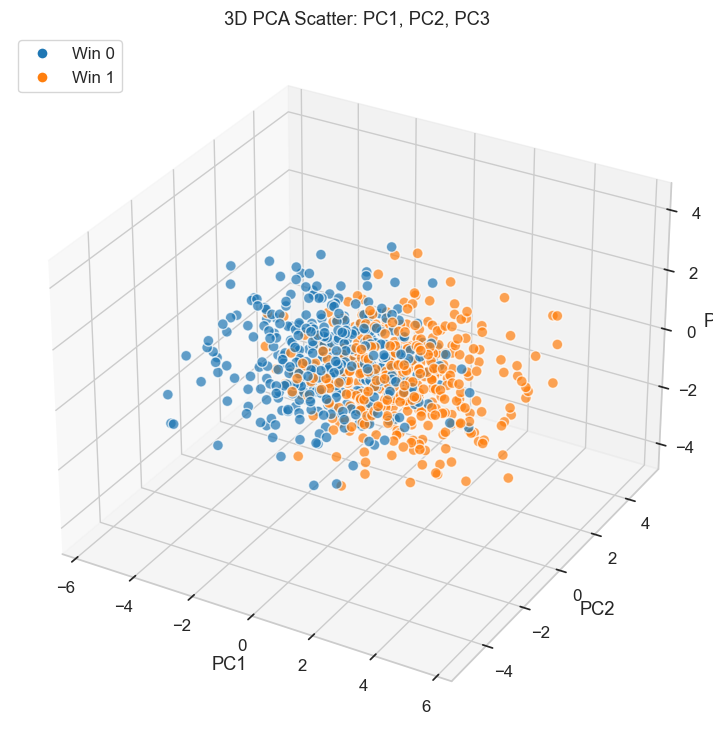

In [9]:
# 3D scatter plot for PC1, PC2, and PC3
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
colors = pca_train_plot['win_label'].map({'0': '#1f77b4', '1': '#ff7f0e'})

ax.scatter(
    pca_train_plot['PC1'],
    pca_train_plot['PC2'],
    pca_train_plot['PC3'],
    c=colors,
    s=60,
    alpha=0.7,
    edgecolors='w'
)
ax.set_title('3D PCA Scatter: PC1, PC2, PC3')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Win 0', markerfacecolor='#1f77b4', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Win 1', markerfacecolor='#ff7f0e', markersize=8)
]
ax.legend(handles=legend_elements, loc='upper left')
plt.show()

In [10]:
# Feature loadings for the first three principal components
loadings = pd.DataFrame(
    pca_model.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
loadings.round(3)

,PC1,PC2,PC3
3P%_diff,0.246,-0.435,0.388
AST_diff,0.406,0.080,0.334
FG%_diff,0.353,-0.265,0.427
FT%_diff,0.135,-0.433,-0.254
SRS_diff,0.433,0.105,-0.367
TOV_diff,0.006,0.542,0.417
TRB_diff,0.328,0.473,0.010
seed_diff,-0.414,-0.117,0.424
win_pct_diff,0.407,-0.064,-0.046


In [11]:
# Transform the test set with the same scaler and PCA model
X_test_scaled = pipeline.named_steps['scaler'].transform(X_test)
X_test_pca = pd.DataFrame(
    pca_model.transform(X_test_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_test.index
)

print('X_train_pca shape:', X_train_pca.shape)
print('X_test_pca shape:', X_test_pca.shape)

X_train_pca.head()

X_train_pca shape: (754, 3)
X_test_pca shape: (314, 3)


,PC1,PC2,PC3
0,2.800673,1.728798,-1.613391
1,1.595223,-1.375904,-0.320133
2,0.502696,2.005143,-2.216379
3,0.239608,-0.864773,1.263662
4,1.691296,1.660130,-0.762817


In [12]:
# Save PCA-transformed datasets to CSV files
X_train_pca.to_csv('data/pca_train_ml.csv', index=False)
X_test_pca.to_csv('data/pca_test_ml.csv', index=False)

combined_pca = pd.concat([
    X_train_pca.assign(dataset='train', win_label=y_train.values, season=train['season'].values),
    X_test_pca.assign(dataset='test', win_label=y_test.values, season=test['season'].values)
], axis=0).reset_index(drop=True)
combined_pca.to_csv('data/pca_all_ml.csv', index=False)

print('Saved X_train_pca to data/pca_train_ml.csv')
print('Saved X_test_pca to data/pca_test_ml.csv')
print('Saved combined PCA dataset to data/pca_all_ml.csv')

Saved X_train_pca to data/pca_train_ml.csv
Saved X_test_pca to data/pca_test_ml.csv
Saved combined PCA dataset to data/pca_all_ml.csv


In [13]:
# Save the full PCA DataFrame to CSV
combined_pca.to_csv('data/pca_df.csv', index=False)
print('Saved PCA combined dataframe to data/pca_df.csv')

Saved PCA combined dataframe to data/pca_df.csv


## Ready for Random Forest Modeling

The PCA-transformed datasets are `X_train_pca` and `X_test_pca`, with targets `y_train` and `y_test`. These can be passed directly into a random forest model with the same training/test structure used in `randomforest.ipynb`.

# PCA Analysis for Tournament Model Data

This notebook performs PCA on `data/tournament_model_ml.csv`, visualizes explained variance and the principal component scores, and produces PCA-transformed train/test datasets that are ready for a random forest pipeline.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [15]:
# Load the dataset
df = pd.read_csv('data/tournament_model_ml.csv')

features = ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff',
            'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']

train = df[df['season'] <= 2022].reset_index(drop=True)
test = df[df['season'] >= 2023].reset_index(drop=True)

X_train = train[features]
y_train = train['win_label']
X_test = test[features]
y_test = test['win_label']

print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print('Feature columns:', features)

Train rows: 754 | Test rows: 314
Feature columns: ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff', 'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']


In [16]:
# Fit PCA with scaling on the training set
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pipeline.fit(X_train)
pca = pipeline.named_steps['pca']
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Explained variance ratio by principal component:')
for i, ratio in enumerate(explained_variance, start=1):
    print(f'  PC{i}: {ratio:.4f}')

print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_variance, start=1):
    print(f'  PC{i}: {cum:.4f}')

Explained variance ratio by principal component:
  PC1: 0.4353
  PC2: 0.2009
  PC3: 0.1224
  PC4: 0.0830
  PC5: 0.0552
  PC6: 0.0399
  PC7: 0.0372
  PC8: 0.0194
  PC9: 0.0066

Cumulative explained variance:
  PC1: 0.4353
  PC2: 0.6362
  PC3: 0.7586
  PC4: 0.8416
  PC5: 0.8968
  PC6: 0.9368
  PC7: 0.9739
  PC8: 0.9934
  PC9: 1.0000


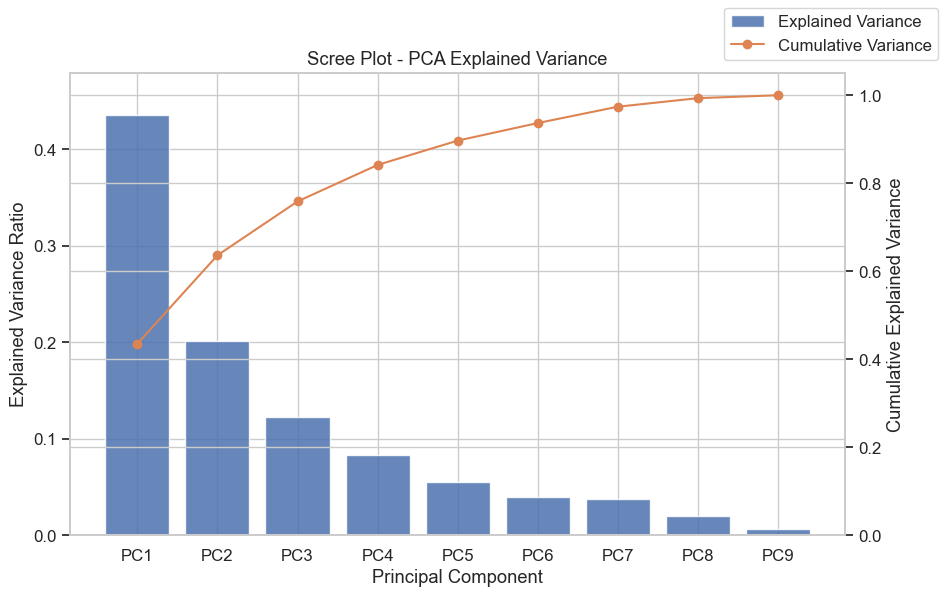

In [17]:
# Scree plot and cumulative variance plot
pc_labels = [f'PC{i+1}' for i in range(len(explained_variance))]

fig, ax1 = plt.subplots()
ax1.bar(pc_labels, explained_variance, color='#4c72b0', alpha=0.85, label='Explained Variance')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component')
ax1.set_title('Scree Plot - PCA Explained Variance')
ax1.set_ylim(0, explained_variance.max() * 1.1)

ax2 = ax1.twinx()
ax2.plot(pc_labels, cumulative_variance, color='#dd8452', marker='o', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

fig.legend(loc='upper right')
plt.show()

In [18]:
# Project the data onto the first three principal components
n_components = 3
pca_model = PCA(n_components=n_components)
X_train_scaled = pipeline.named_steps['scaler'].transform(X_train)
X_train_pca = pd.DataFrame(
    pca_model.fit_transform(X_train_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_train.index
)
train_pca_inspect = pd.concat([train[['season', 'win_label']].reset_index(drop=True), X_train_pca.reset_index(drop=True)], axis=1)
train_pca_inspect.head()

,season,win_label,PC1,PC2,PC3
0,2015,1,2.800673,1.728798,-1.613391
1,2015,1,1.595223,-1.375904,-0.320133
2,2015,1,0.502696,2.005143,-2.216379
3,2015,1,0.239608,-0.864773,1.263662
4,2015,1,1.691296,1.660130,-0.762817


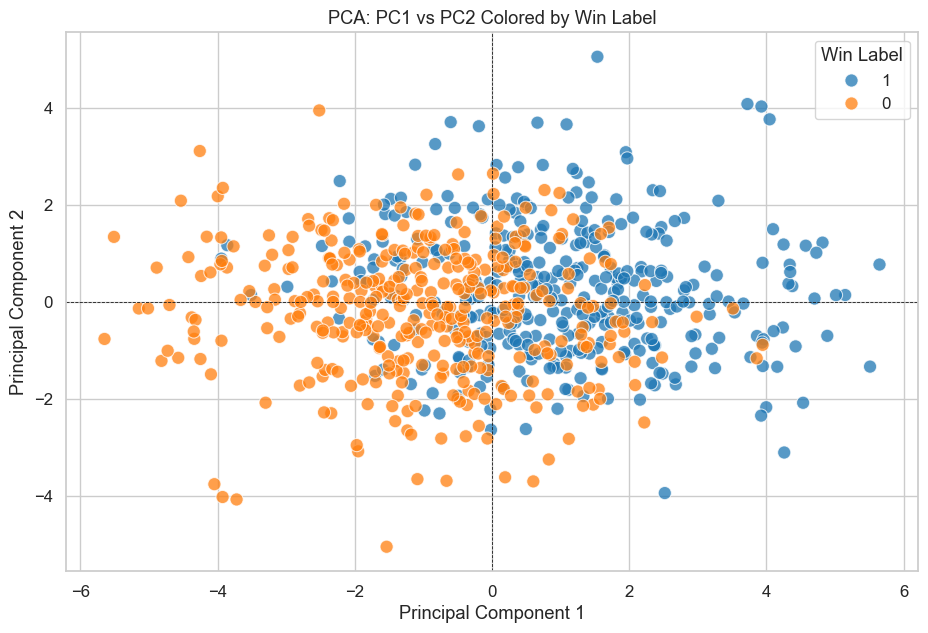

In [19]:
# 2D scatter plot for PC1 vs PC2
pca_train_plot = train_pca_inspect.copy()
pca_train_plot['win_label'] = pca_train_plot['win_label'].astype(str)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_train_plot,
    x='PC1',
    y='PC2',
    hue='win_label',
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.75,
    edgecolor='w',
    s=90
)
plt.title('PCA: PC1 vs PC2 Colored by Win Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Win Label')
plt.axhline(0, color='k', linewidth=0.6, linestyle='--')
plt.axvline(0, color='k', linewidth=0.6, linestyle='--')
plt.show()

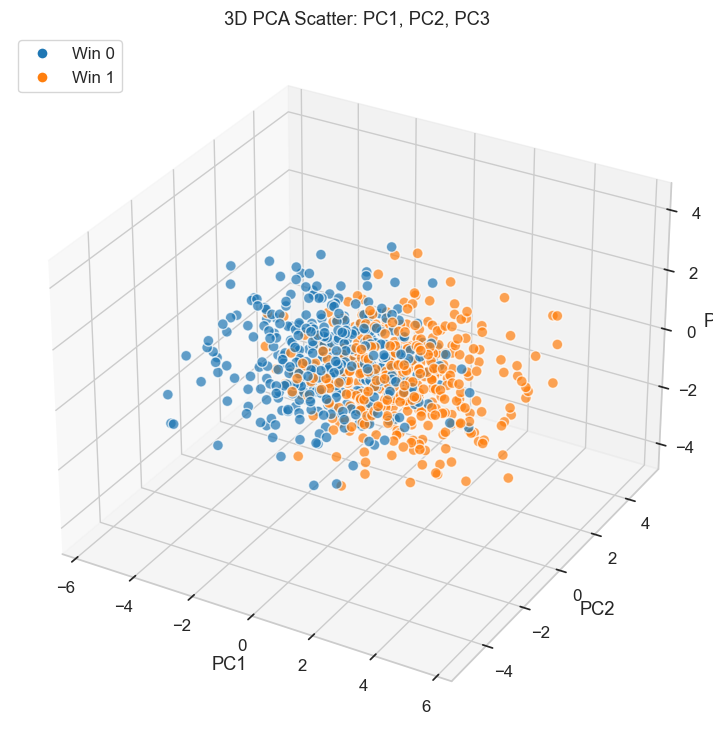

In [20]:
# 3D scatter plot for PC1, PC2, and PC3
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
colors = pca_train_plot['win_label'].map({'0': '#1f77b4', '1': '#ff7f0e'})

ax.scatter(
    pca_train_plot['PC1'],
    pca_train_plot['PC2'],
    pca_train_plot['PC3'],
    c=colors,
    s=60,
    alpha=0.7,
    edgecolors='w'
)
ax.set_title('3D PCA Scatter: PC1, PC2, PC3')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Win 0', markerfacecolor='#1f77b4', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Win 1', markerfacecolor='#ff7f0e', markersize=8)
]
ax.legend(handles=legend_elements, loc='upper left')
plt.show()

In [21]:
# Feature loadings for the first three principal components
loadings = pd.DataFrame(
    pca_model.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
loadings.round(3)

,PC1,PC2,PC3
3P%_diff,0.246,-0.435,0.388
AST_diff,0.406,0.080,0.334
FG%_diff,0.353,-0.265,0.427
FT%_diff,0.135,-0.433,-0.254
SRS_diff,0.433,0.105,-0.367
TOV_diff,0.006,0.542,0.417
TRB_diff,0.328,0.473,0.010
seed_diff,-0.414,-0.117,0.424
win_pct_diff,0.407,-0.064,-0.046


In [22]:
# Transform the test set with the same scaler and PCA model
X_test_scaled = pipeline.named_steps['scaler'].transform(X_test)
X_test_pca = pd.DataFrame(
    pca_model.transform(X_test_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_test.index
)

print('X_train_pca shape:', X_train_pca.shape)
print('X_test_pca shape:', X_test_pca.shape)

X_train_pca.head()

X_train_pca shape: (754, 3)
X_test_pca shape: (314, 3)


,PC1,PC2,PC3
0,2.800673,1.728798,-1.613391
1,1.595223,-1.375904,-0.320133
2,0.502696,2.005143,-2.216379
3,0.239608,-0.864773,1.263662
4,1.691296,1.660130,-0.762817


## Ready for Random Forest Modeling

The PCA-transformed datasets are `X_train_pca` and `X_test_pca`, with targets `y_train` and `y_test`. These can be passed directly into a random forest model with the same training/test structure used in `randomforest.ipynb`.

# PCA Analysis for Tournament Model Data

This notebook performs principal component analysis on `data/tournament_model_ml.csv`, shows explained variance and component structure, and produces PCA-transformed train/test sets that are ready to plug into a random forest pipeline.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [24]:
# Load the dataset
df = pd.read_csv('data/tournament_model_ml.csv')

# Define the feature set used for PCA
features = ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff',
            'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']

# Train/test split by season to mirror the modeling approach in randomforest.ipynb
train = df[df['season'] <= 2022].reset_index(drop=True)
test = df[df['season'] >= 2023].reset_index(drop=True)

X_train = train[features]
y_train = train['win_label']
X_test = test[features]
y_test = test['win_label']

print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print('Feature columns:', features)

Train rows: 754 | Test rows: 314
Feature columns: ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff', 'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']


In [25]:
# Build a pipeline with scaling and PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pca_pipeline.fit(X_train)
pca = pca_pipeline.named_steps['pca']
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Explained variance ratio by principal component:')
for i, ratio in enumerate(explained_variance, start=1):
    print(f'  PC{i}: {ratio:.4f}')

print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_variance, start=1):
    print(f'  PC{i}: {cum:.4f}')

Explained variance ratio by principal component:
  PC1: 0.4353
  PC2: 0.2009
  PC3: 0.1224
  PC4: 0.0830
  PC5: 0.0552
  PC6: 0.0399
  PC7: 0.0372
  PC8: 0.0194
  PC9: 0.0066

Cumulative explained variance:
  PC1: 0.4353
  PC2: 0.6362
  PC3: 0.7586
  PC4: 0.8416
  PC5: 0.8968
  PC6: 0.9368
  PC7: 0.9739
  PC8: 0.9934
  PC9: 1.0000


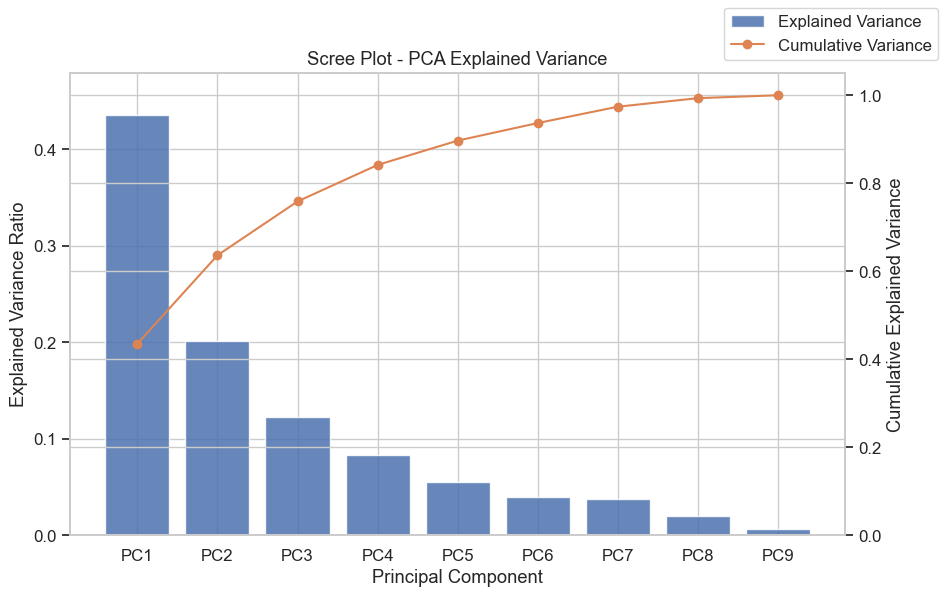

In [26]:
# Visualize the explained variance
pc_labels = [f'PC{i+1}' for i in range(len(explained_variance))]

fig, ax1 = plt.subplots()
ax1.bar(pc_labels, explained_variance, color='#4c72b0', alpha=0.85, label='Explained Variance')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component')
ax1.set_title('Scree Plot - PCA Explained Variance')
ax1.set_ylim(0, explained_variance.max() * 1.1)

ax2 = ax1.twinx()
ax2.plot(pc_labels, cumulative_variance, color='#dd8452', marker='o', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

fig.legend(loc='upper right')
plt.show()

In [27]:
# Build a DataFrame with PCA scores for the training data
n_components = 3

pca_model = PCA(n_components=n_components)
X_train_scaled = pca_pipeline.named_steps['scaler'].transform(X_train)
X_train_pca = pd.DataFrame(
    pca_model.fit_transform(X_train_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_train.index
)

# Attach the target and season for inspection only
train_pca_inspect = pd.concat([train[['season', 'win_label']].reset_index(drop=True), X_train_pca.reset_index(drop=True)], axis=1)
train_pca_inspect.head()

,season,win_label,PC1,PC2,PC3
0,2015,1,2.800673,1.728798,-1.613391
1,2015,1,1.595223,-1.375904,-0.320133
2,2015,1,0.502696,2.005143,-2.216379
3,2015,1,0.239608,-0.864773,1.263662
4,2015,1,1.691296,1.660130,-0.762817


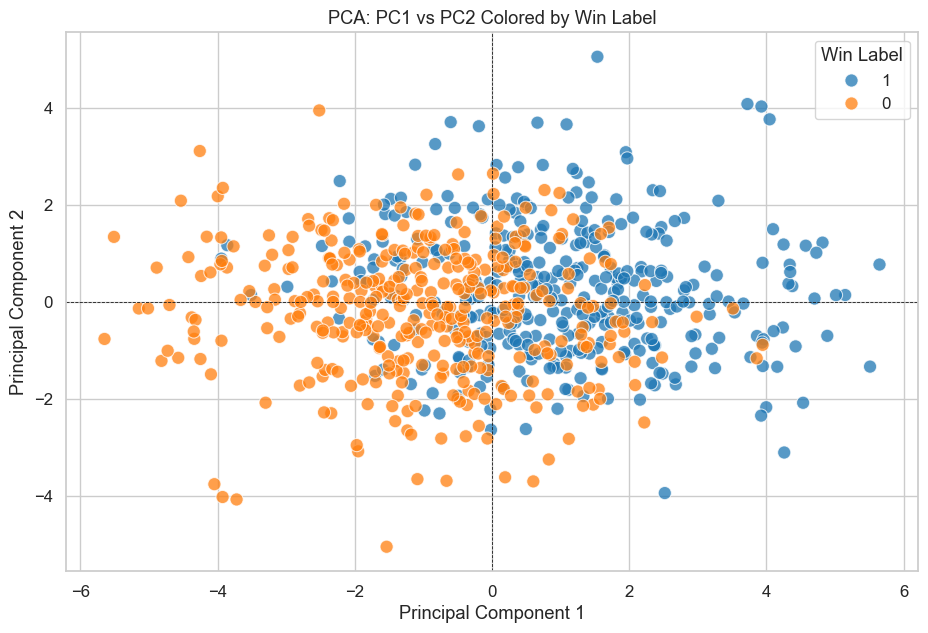

In [28]:
# Scatter plot of the first two principal components
pca_train_plot = train_pca_inspect.copy()
pca_train_plot['win_label'] = pca_train_plot['win_label'].astype(str)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_train_plot,
    x='PC1',
    y='PC2',
    hue='win_label',
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.75,
    edgecolor='w',
    s=90
)
plt.title('PCA: PC1 vs PC2 Colored by Win Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Win Label')
plt.axhline(0, color='k', linewidth=0.6, linestyle='--')
plt.axvline(0, color='k', linewidth=0.6, linestyle='--')
plt.show()

In [29]:
# Compare feature loadings for the first three principal components
loadings = pd.DataFrame(
    pca_model.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

loadings.round(3)

,PC1,PC2,PC3
3P%_diff,0.246,-0.435,0.388
AST_diff,0.406,0.080,0.334
FG%_diff,0.353,-0.265,0.427
FT%_diff,0.135,-0.433,-0.254
SRS_diff,0.433,0.105,-0.367
TOV_diff,0.006,0.542,0.417
TRB_diff,0.328,0.473,0.010
seed_diff,-0.414,-0.117,0.424
win_pct_diff,0.407,-0.064,-0.046


In [30]:
# Transform the test set with the same scaler and PCA model
X_test_scaled = pca_pipeline.named_steps['scaler'].transform(X_test)
X_test_pca = pd.DataFrame(
    pca_model.transform(X_test_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_test.index
)

# Show the ready-to-use PCA datasets for random forest modeling
print('X_train_pca shape:', X_train_pca.shape)
print('X_test_pca shape:', X_test_pca.shape)

X_train_pca.head()

X_train_pca shape: (754, 3)
X_test_pca shape: (314, 3)


,PC1,PC2,PC3
0,2.800673,1.728798,-1.613391
1,1.595223,-1.375904,-0.320133
2,0.502696,2.005143,-2.216379
3,0.239608,-0.864773,1.263662
4,1.691296,1.660130,-0.762817


## Ready for Random Forest Modeling

The PCA-transformed inputs are stored in `X_train_pca` and `X_test_pca`, and the target vectors are `y_train` and `y_test`. This matches the training pattern used in `randomforest.ipynb`, but with the original feature set replaced by the top principal components.

# PCA Analysis for Tournament Model Data

This notebook performs principal component analysis on `data/tournament_model_ml.csv`, shows the explained variance and component structure, and produces PCA-transformed train/test sets that are ready to plug into a random forest pipeline.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [32]:
# Load the dataset
df = pd.read_csv('data/tournament_model_ml.csv')

# Define the feature set used for PCA
features = ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff',
            'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']

# Train/test split by season to mirror the modeling approach in randomforest.ipynb
train = df[df['season'] <= 2022].reset_index(drop=True)
test = df[df['season'] >= 2023].reset_index(drop=True)

X_train = train[features]
y_train = train['win_label']
X_test = test[features]
y_test = test['win_label']

print(f'Train rows: {len(train)} | Test rows: {len(test)}')
print('Feature columns:', features)

Train rows: 754 | Test rows: 314
Feature columns: ['3P%_diff', 'AST_diff', 'FG%_diff', 'FT%_diff', 'SRS_diff', 'TOV_diff', 'TRB_diff', 'seed_diff', 'win_pct_diff']


In [33]:
# Build a pipeline with scaling and PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pca_pipeline.fit(X_train)
pca = pca_pipeline.named_steps['pca']
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Explained variance ratio by principal component:')
for i, ratio in enumerate(explained_variance, start=1):
    print(f'  PC{i}: {ratio:.4f}')

print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_variance, start=1):
    print(f'  PC{i}: {cum:.4f}')

Explained variance ratio by principal component:
  PC1: 0.4353
  PC2: 0.2009
  PC3: 0.1224
  PC4: 0.0830
  PC5: 0.0552
  PC6: 0.0399
  PC7: 0.0372
  PC8: 0.0194
  PC9: 0.0066

Cumulative explained variance:
  PC1: 0.4353
  PC2: 0.6362
  PC3: 0.7586
  PC4: 0.8416
  PC5: 0.8968
  PC6: 0.9368
  PC7: 0.9739
  PC8: 0.9934
  PC9: 1.0000


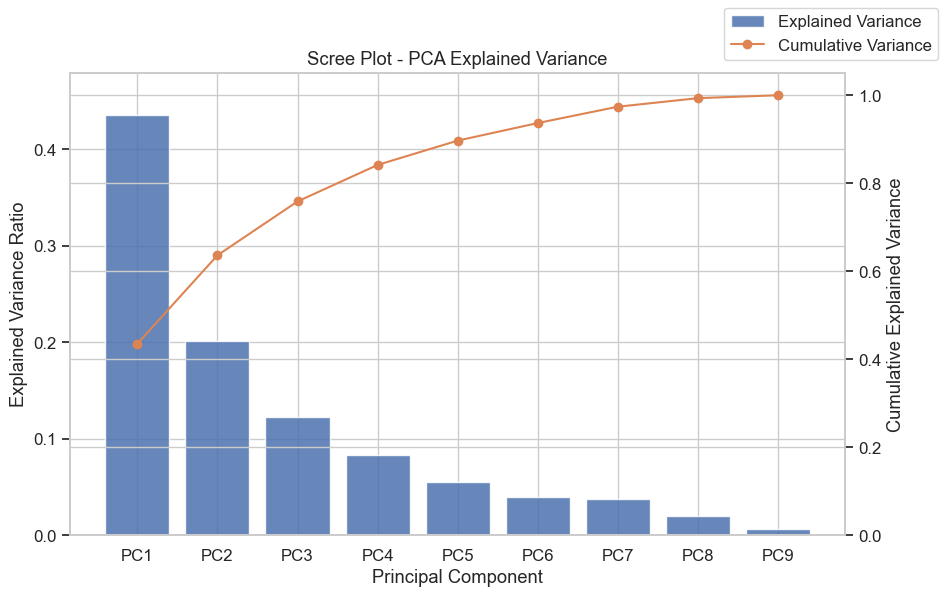

In [34]:
# Visualize the explained variance
pc_labels = [f'PC{i+1}' for i in range(len(explained_variance))]

fig, ax1 = plt.subplots()
ax1.bar(pc_labels, explained_variance, color='#4c72b0', alpha=0.85, label='Explained Variance')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component')
ax1.set_title('Scree Plot - PCA Explained Variance')
ax1.set_ylim(0, explained_variance.max() * 1.1)

ax2 = ax1.twinx()
ax2.plot(pc_labels, cumulative_variance, color='#dd8452', marker='o', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

fig.legend(loc='upper right')
plt.show()

In [35]:
# Build a DataFrame with PCA scores for the training data
n_components = 5

pca_model = PCA(n_components=n_components)
X_train_scaled = pca_pipeline.named_steps['scaler'].transform(X_train)
X_train_pca = pd.DataFrame(
    pca_model.fit_transform(X_train_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_train.index
)

# Attach the target and season for inspection only
train_pca_inspect = pd.concat([train[['season', 'win_label']].reset_index(drop=True), X_train_pca.reset_index(drop=True)], axis=1)
train_pca_inspect.head()

,season,win_label,PC1,PC2,PC3,PC4,PC5
0,2015,1,2.800673,1.728798,-1.613391,-0.892030,0.032412
1,2015,1,1.595223,-1.375904,-0.320133,-0.034403,0.816271
2,2015,1,0.502696,2.005143,-2.216379,-0.384930,-0.744607
3,2015,1,0.239608,-0.864773,1.263662,-0.535760,0.177750
4,2015,1,1.691296,1.660130,-0.762817,0.232597,0.739918


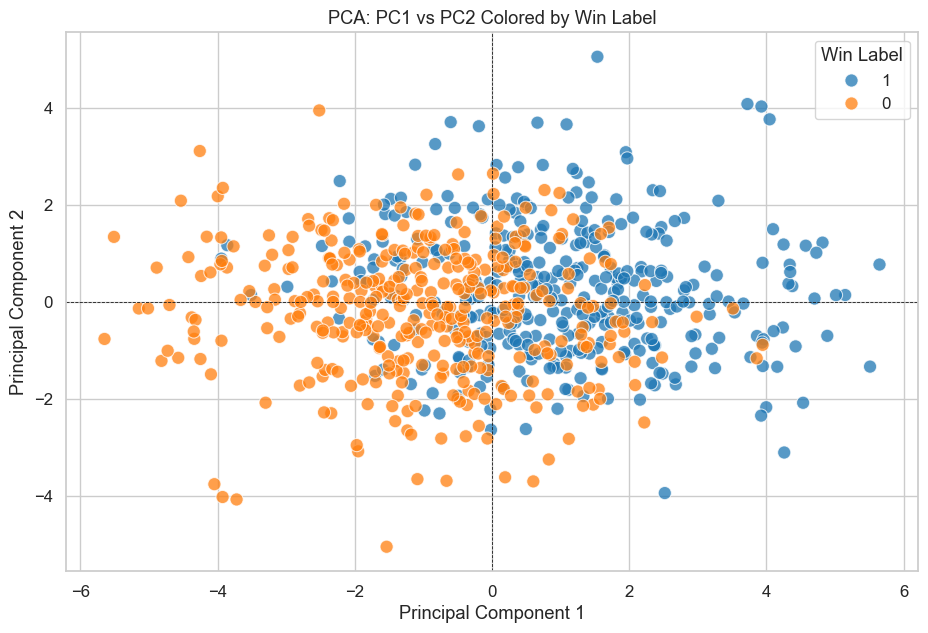

In [36]:
# Scatter plot of the first two principal components
pca_train_plot = train_pca_inspect.copy()
pca_train_plot['win_label'] = pca_train_plot['win_label'].astype(str)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_train_plot,
    x='PC1',
    y='PC2',
    hue='win_label',
    palette=['#1f77b4', '#ff7f0e'],
    alpha=0.75,
    edgecolor='w',
    s=90
)
plt.title('PCA: PC1 vs PC2 Colored by Win Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Win Label')
plt.axhline(0, color='k', linewidth=0.6, linestyle='--')
plt.axvline(0, color='k', linewidth=0.6, linestyle='--')
plt.show()

In [37]:
# Compare feature loadings for the first three principal components
loadings = pd.DataFrame(
    pca_model.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5
3P%_diff,0.246,-0.435,0.388,0.068,0.561
AST_diff,0.406,0.080,0.334,0.042,-0.143
FG%_diff,0.353,-0.265,0.427,-0.143,-0.134
FT%_diff,0.135,-0.433,-0.254,0.791,-0.318
SRS_diff,0.433,0.105,-0.367,0.001,0.322
TOV_diff,0.006,0.542,0.417,0.496,0.120
TRB_diff,0.328,0.473,0.010,0.090,-0.191
seed_diff,-0.414,-0.117,0.424,-0.000,-0.348
win_pct_diff,0.407,-0.064,-0.046,-0.304,-0.519


In [38]:
# Transform the test set with the same scaler and PCA model
X_test_scaled = pca_pipeline.named_steps['scaler'].transform(X_test)
X_test_pca = pd.DataFrame(
    pca_model.transform(X_test_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_test.index
)

# Show the ready-to-use PCA datasets for random forest modeling
print('X_train_pca shape:', X_train_pca.shape)
print('X_test_pca shape:', X_test_pca.shape)

X_train_pca.head()

X_train_pca shape: (754, 5)
X_test_pca shape: (314, 5)


,PC1,PC2,PC3,PC4,PC5
0,2.800673,1.728798,-1.613391,-0.892030,0.032412
1,1.595223,-1.375904,-0.320133,-0.034403,0.816271
2,0.502696,2.005143,-2.216379,-0.384930,-0.744607
3,0.239608,-0.864773,1.263662,-0.535760,0.177750
4,1.691296,1.660130,-0.762817,0.232597,0.739918


## Ready for Random Forest Modeling

The PCA-transformed inputs are stored in `X_train_pca` and `X_test_pca`, and the target vectors are `y_train` and `y_test`. This matches the training pattern used in `randomforest.ipynb`, but with the original feature set replaced by the top principal components.

## Random Forest Model with PCA Components

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [40]:
pca_features = [f'PC{i+1}' for i in range(n_components)]

param_dist = {
    'n_estimators':      (100,800),
    'max_depth': [None] + list(range(5, 31)),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 8),
    'max_features':      ['sqrt', 'log2', None],
    'bootstrap':         [True, False]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Randomized search — tries 50 random combinations, 5-fold CV
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,           # number of random combos to try
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',   # optimize for accuracy
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [41]:
search.fit(X_train_pca, y_train)

print(f"\nBest Parameters: {search.best_params_}")
print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate best model on test set
best_rf = search.best_estimator_

y_pred  = best_rf.predict(X_test_pca)
y_proba = best_rf.predict_proba(X_test_pca)[:, 1]

print(f"\nTest Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# Feature importances from best model
importances = sorted(zip(pca_features, best_rf.feature_importances_),
                     key=lambda x: x[1], reverse=True)
print("\nFeature Importances:")
for feat, imp in importances:
    print(f"  {feat:<15} {imp:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'bootstrap': True, 'max_depth': 29, 'max_features': 'log2', 'min_samples_leaf': 7, 'min_samples_split': 3, 'n_estimators': 100}
Best CV AUC:     0.7414

Test Accuracy:  0.7548
Test ROC-AUC:   0.8373

Confusion Matrix:
[[119  38]
 [ 39 118]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.76       157
           1       0.76      0.75      0.75       157

    accuracy                           0.75       314
   macro avg       0.75      0.75      0.75       314
weighted avg       0.75      0.75      0.75       314


Feature Importances:
  PC1             0.5752
  PC2             0.1407
  PC3             0.1050
  PC4             0.0928
  PC5             0.0863


Insight
Integrating Principal Component Analysis with the Random Forest model revealed that tournament success is highly concentrated in a single strength dimension. PC1 alone accounted for approximately 43.5% of the total variance and emerged as the dominant predictor, carrying over 57% of the model's feature importance. By examining the loadings, we can see that PC1 effectively synthesizes team quality by heavily weighing SRS (Simple Rating System) differences, win percentages, and seeding. Interestingly, while the original Random Forest relied on a broad array of individual stats, the PCA-augmented model achieved a competitive 75.5% test accuracy using only five components. This suggests that once a team’s core dominance and efficiency/turnover balance are established, additional smaller statistics provide diminishing returns for tournament prediction. The RF model alone was 76 accuracy, so it was slightly better than the PCA one.

The analysis demonstrates that NCAA tournament outcomes can be predicted with a high degree of reliability by distilling complex box-score differentials into a few latent dimensions of team quality. While the original Random Forest model performed just as effectively as the PCA-augmented version, the use of dimensionality reduction provided a much clearer view of which underlying factors drive winning. This hybrid approach successfully maintained an 0.837 ROC-AUC, proving that we can significantly simplify the model's input structure without sacrificing any predictive accuracy or the ability to identify tournament winners.